## 实操：全球估值近30年收益走势图

#### AI Prompt

请帮我实现一个notebook脚本，可视化使用plotly库，具体功能如下：
1. 通过yfinance获取指数历史数据并保存：上证、恒生、标普、纳斯达克、欧元、日经、孟买
2. 读取同路径下的指数csv数据
3. 描述数据的基本情况：长度、起始日期、结束日期、年跨度
4. 展示不同指数的价格对比图
5. 计算并对比不同指数的收益与回撤，统计口径包括：累计值、平均年化、逐年年化
6. 展示不同指数的收益和回撤情况：总的、逐年年化的

可选：参考 @17.3 实现对全球股指的分析，包括：上证、恒生、标普、纳斯达克、欧元、日经、孟买

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly import colors as pc
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="Glyph .* missing from font", category=UserWarning)

DATA_DIR = Path(".")  # 指向存放 index CSV 的目录，默认当前目录
DATA_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
INDEX_MAP = {
    "SSE_上证综指": "000001.SS",
    "HSI_恒生": "^HSI",
    "GSPC_标普500": "^GSPC",
    "IXIC_纳斯达克": "^IXIC",
    "STOXX50E_欧元区": "^STOXX50E",  # Euro Stoxx 50
    "N225_日经225": "^N225",
    "BSESN_孟买Sensex": "^BSESN",
    # 指数其他
}

list(INDEX_MAP.items())


[('SSE_上证综指', '000001.SS'),
 ('HSI_恒生', '^HSI'),
 ('GSPC_标普500', '^GSPC'),
 ('IXIC_纳斯达克', '^IXIC'),
 ('STOXX50E_欧元区', '^STOXX50E'),
 ('N225_日经225', '^N225'),
 ('BSESN_孟买Sensex', '^BSESN')]

In [3]:
DOWNLOAD = False  # 改为 True 以触发下载

if DOWNLOAD:
    for name, ticker in INDEX_MAP.items():
        print(f"Downloading {name} ({ticker}) ...")
        df = yf.download(ticker, period="max", progress=False)
        if df.empty:
            print(f"✗ {name}: no data")
            continue
        df = df.reset_index()
        df.to_csv(DATA_DIR / f"{name}.csv", index=False, encoding="utf-8-sig")
        df["Date"] = pd.to_datetime(df["Date"])
        print(f"✓ {name}: {len(df)} rows | {df['Date'].iloc[0].date()} -> {df['Date'].iloc[-1].date()}")


In [4]:
missing = []
data_frames = {}

for name in INDEX_MAP.keys():
    path = DATA_DIR / f"{name}.csv"
    if not path.exists():
        missing.append(path)
        continue
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df.get("Date"), errors="coerce")
    df["Close"] = pd.to_numeric(df.get("Close"), errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date")
    data_frames[name] = df

if missing:
    raise FileNotFoundError(
        f"未找到文件: {', '.join(str(p) for p in missing)} (DATA_DIR={DATA_DIR})"
    )

if not data_frames:
    raise FileNotFoundError(f"DATA_DIR={DATA_DIR} 未找到任何指数 CSV")

list(data_frames.keys())

['SSE_上证综指',
 'HSI_恒生',
 'GSPC_标普500',
 'IXIC_纳斯达克',
 'STOXX50E_欧元区',
 'N225_日经225',
 'BSESN_孟买Sensex']

In [5]:
# 统一颜色映射，保证各图一致
index_names = list(data_frames.keys())
color_palette = pc.qualitative.Set2
# 若指数数目超过配色长度则循环使用
color_map = {name: color_palette[i % len(color_palette)] for i, name in enumerate(index_names)}

In [6]:
overview_rows = []
for name, df in data_frames.items():
    # 清理缺失日期，避免 NaT / NaN
    df_clean = df.dropna(subset=["Date"]).copy()
    df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
    df_clean = df_clean.dropna(subset=["Date"]).sort_values("Date")

    start, end = df_clean["Date"].iloc[0], df_clean["Date"].iloc[-1]
    years = (end - start).days / 365.25
    overview_rows.append(
        {
            "index": name,
            "rows": len(df_clean),
            "start": start.date(),
            "end": end.date(),
            "years": round(years, 2),
        }
    )

overview_df = pd.DataFrame(overview_rows).set_index("index")
overview_df

,rows,start,end,years
index,,,,
SSE_上证综指,6892,1997-07-02,2025-12-11,28.44
HSI_恒生,9614,1986-12-31,2025-12-11,38.95
GSPC_标普500,24603,1927-12-30,2025-12-10,97.95
IXIC_纳斯达克,13829,1971-02-05,2025-12-10,54.84
STOXX50E_欧元区,4690,2007-03-30,2025-12-10,18.70
N225_日经225,14983,1965-01-05,2025-12-11,60.93
BSESN_孟买Sensex,7009,1997-07-01,2025-12-11,28.45


In [7]:
def compute_metrics(df: pd.DataFrame) -> dict:
    """计算总收益、最大回撤及年化指标。"""
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date")
    df = df.set_index("Date")

    close = df["Close"].astype(float)
    if close.empty:
        return {"total_return": np.nan, "max_drawdown": np.nan, "annualized_return": np.nan, "annualized_max_dd": np.nan}

    days = (close.index[-1] - close.index[0]).days or 1
    total_return = close.iloc[-1] / close.iloc[0] - 1

    cum = close / close.iloc[0]
    running_max = cum.cummax()
    drawdown = cum / running_max - 1
    max_drawdown = drawdown.min()

    annualized_return = (1 + total_return) ** (365.25 / days) - 1
    # 将最大回撤折算为年化幅度，便于跨周期可比（结果为负值）
    annualized_max_dd = 1 - (1 + max_drawdown) ** (365.25 / days)

    return {
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "annualized_return": annualized_return,
        "annualized_max_dd": annualized_max_dd,
    }


def compute_yearly_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """按年度计算收益和最大回撤。"""
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date")
    df = df.set_index("Date")

    records = []
    for year, group in df.groupby(df.index.year):
        close = group["Close"].astype(float)
        if close.empty:
            continue
        total_return = close.iloc[-1] / close.iloc[0] - 1
        cum = close / close.iloc[0]
        dd = (cum / cum.cummax() - 1).min()
        records.append({"year": year, "return": total_return, "drawdown": dd})

    return pd.DataFrame(records)

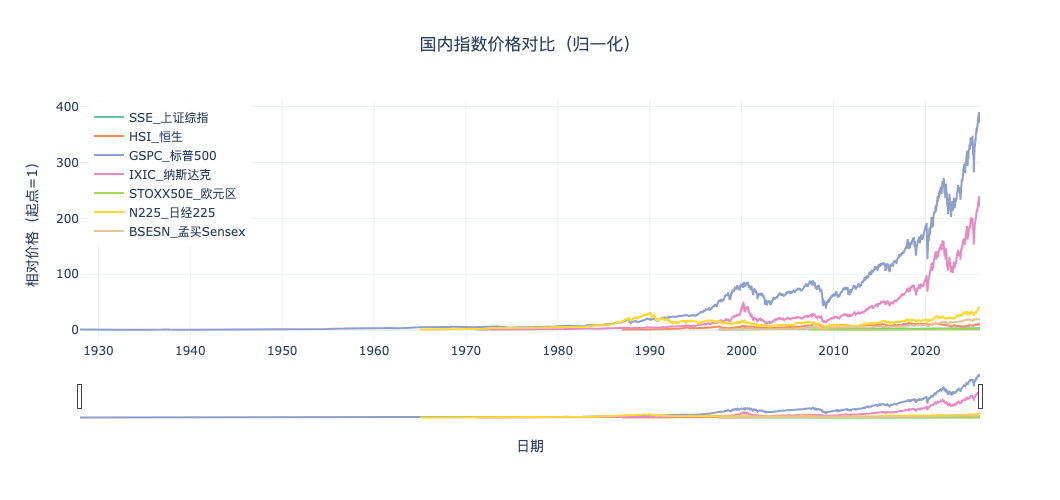

In [8]:
# 1) 价格对比（归一化到 1）
fig = go.Figure()

for name, df in data_frames.items():
    df_plot = df.dropna(subset=["Date", "Close"]).sort_values("Date")
    df_plot["Date"] = pd.to_datetime(df_plot["Date"], errors="coerce")
    base = df_plot["Close"].iloc[0]
    fig.add_trace(
        go.Scatter(
            x=df_plot["Date"],
            y=df_plot["Close"] / base,
            mode="lines",
            name=name,
            line=dict(color=color_map.get(name), width=2),
            hovertemplate="<b>%{fullData.name}</b><br>日期: %{x|%Y-%m-%d}<br>相对价格: %{y:.4f}<extra></extra>",
        )
    )

fig.update_layout(
    title={"text": "国内指数价格对比（归一化）", "x": 0.5},
    xaxis_title="日期",
    yaxis_title="相对价格（起点=1）",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    height=500,
    width=1080,
)
fig.update_xaxes(rangeslider=dict(visible=True))
fig.show()



In [9]:
# 2) 总收益与年化收益 + 最大回撤
summary_rows = []
for name, df in data_frames.items():
    metrics = compute_metrics(df)
    summary_rows.append({"index": name, **metrics})

summary_df = pd.DataFrame(summary_rows).set_index("index")
# 展示时转为百分比格式（NaN 显示为空，无 % 符号）
summary_df_display = summary_df.applymap(lambda v: "" if pd.isna(v) else f"{v * 100:.2f}")
summary_df_display

,total_return,max_drawdown,annualized_return,annualized_max_dd
index,,,,
SSE_上证综指,223.03,-71.98,4.21,4.37
HSI_恒生,893.38,-65.18,6.07,2.67
GSPC_标普500,38895.92,-86.19,6.28,2.00
IXIC_纳斯达克,23554.15,-77.93,10.48,2.72
STOXX50E_欧元区,36.52,-60.29,1.68,4.82
N225_日经225,3887.28,-81.87,6.24,2.76
BSESN_孟买Sensex,1871.68,-60.91,11.05,3.25


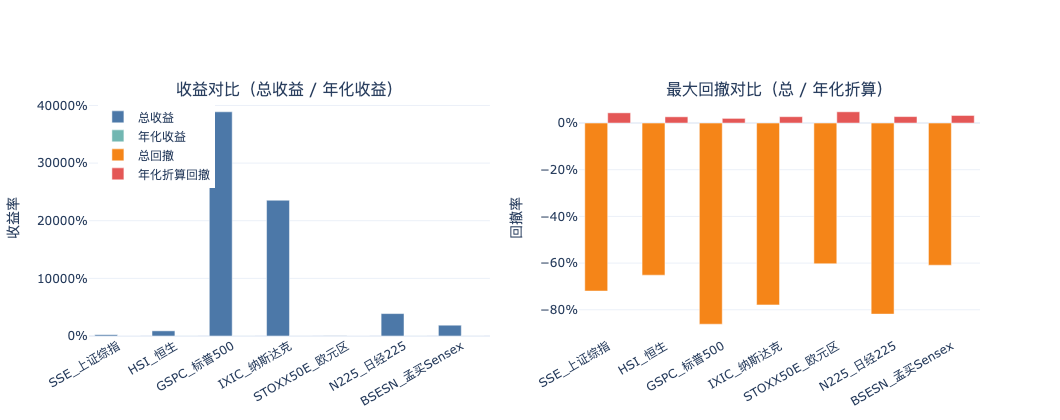

In [10]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("收益对比（总收益 / 年化收益）", "最大回撤对比（总 / 年化折算）"))

# 收益对比
fig.add_trace(
    go.Bar(
        x=summary_df.index,
        y=summary_df["total_return"],
        name="总收益",
        marker_color="#4c78a8",
        hovertemplate="指数: %{x}<br>总收益: %{y:.2%}<extra></extra>",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=summary_df.index,
        y=summary_df["annualized_return"],
        name="年化收益",
        marker_color="#72b7b2",
        hovertemplate="指数: %{x}<br>年化收益: %{y:.2%}<extra></extra>",
    ),
    row=1,
    col=1,
)

# 回撤对比
fig.add_trace(
    go.Bar(
        x=summary_df.index,
        y=summary_df["max_drawdown"],
        name="总回撤",
        marker_color="#f58518",
        hovertemplate="指数: %{x}<br>总回撤: %{y:.2%}<extra></extra>",
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Bar(
        x=summary_df.index,
        y=summary_df["annualized_max_dd"],
        name="年化折算回撤",
        marker_color="#e45756",
        hovertemplate="指数: %{x}<br>年化折算回撤: %{y:.2%}<extra></extra>",
    ),
    row=1,
    col=2,
)

fig.update_layout(
    template="plotly_white",
    height=420,
    width=1080,
    barmode="group",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.update_yaxes(title_text="收益率", tickformat=".0%", row=1, col=1)
fig.update_yaxes(title_text="回撤率", tickformat=".0%", row=1, col=2)
fig.update_xaxes(tickangle=-30)
fig.show()

In [11]:
# 3) 逐年收益与回撤
yearly_frames = []
for name, df in data_frames.items():
    ydf = compute_yearly_metrics(df)
    if ydf.empty:
        continue
    ydf["index"] = name
    yearly_frames.append(ydf)

if not yearly_frames:
    raise RuntimeError("逐年数据为空，检查输入数据")

yearly_df = pd.concat(yearly_frames, ignore_index=True)
yearly_df_pivot_return = yearly_df.pivot(index="year", columns="index", values="return").sort_index()
yearly_df_pivot_dd = yearly_df.pivot(index="year", columns="index", values="drawdown").sort_index()

# 展示为百分比（NaN 为空，无 % 符号）
yearly_df_pivot_return_display = yearly_df_pivot_return.applymap(lambda v: "" if pd.isna(v) else f"{v * 100:.2f}")
yearly_df_pivot_return_display

index,BSESN_孟买Sensex,GSPC_标普500,HSI_恒生,IXIC_纳斯达克,N225_日经225,SSE_上证综指,STOXX50E_欧元区
year,,,,,,,
1927,,0.00,,,,,
1928,,37.11,,,,,
1929,,-13.54,,,,,
1930,,-27.57,,,,,
1931,,-48.77,,,,,
...,...,...,...,...,...,...,...
2021,21.69,28.79,-14.83,23.20,5.63,3.91,20.81
2022,2.80,-19.95,-15.01,-33.89,-10.95,-14.95,-12.42
2023,18.10,24.73,-15.38,44.52,30.13,-4.54,16.47


In [12]:
yearly_df_pivot_return_display.tail(30)

index,BSESN_孟买Sensex,GSPC_标普500,HSI_恒生,IXIC_纳斯达克,N225_日经225,SSE_上证综指,STOXX50E_欧元区
year,,,,,,,
1996,,19.33,31.81,21.95,-6.09,,
1997,-14.92,31.67,-18.79,22.62,-21.53,-0.41,
1998,-17.30,26.07,-5.92,38.64,-7.45,-6.04,
1999,60.34,19.64,72.92,84.29,41.13,21.39,
2000,-26.10,-9.27,-13.09,-40.20,-27.45,47.43,
2001,-18.82,-10.53,-23.35,-14.90,-23.00,-21.75,
2002,3.31,-23.80,-17.88,-32.52,-21.09,-15.75,
2003,73.52,22.32,34.28,44.66,22.53,13.36,
2004,9.56,9.33,11.16,8.41,6.13,-16.52,


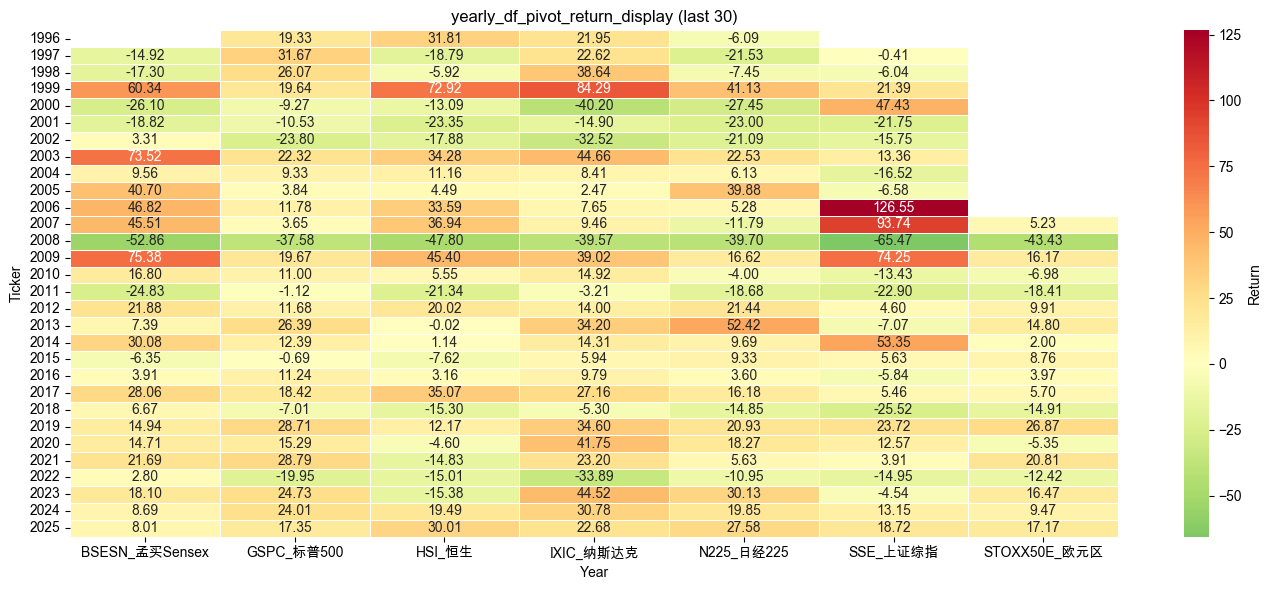

In [13]:
# 设置中文字体显示
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

heatmap_df = (
    yearly_df_pivot_return_display.tail(30)
    .replace("", np.nan)
    .apply(pd.to_numeric, errors="coerce")
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_df,
    cmap="RdYlGn_r",  # reversed so higher (profit) is red, lower (loss) is green
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Return"},
)
plt.title("yearly_df_pivot_return_display (last 30)")
plt.xlabel("Year")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

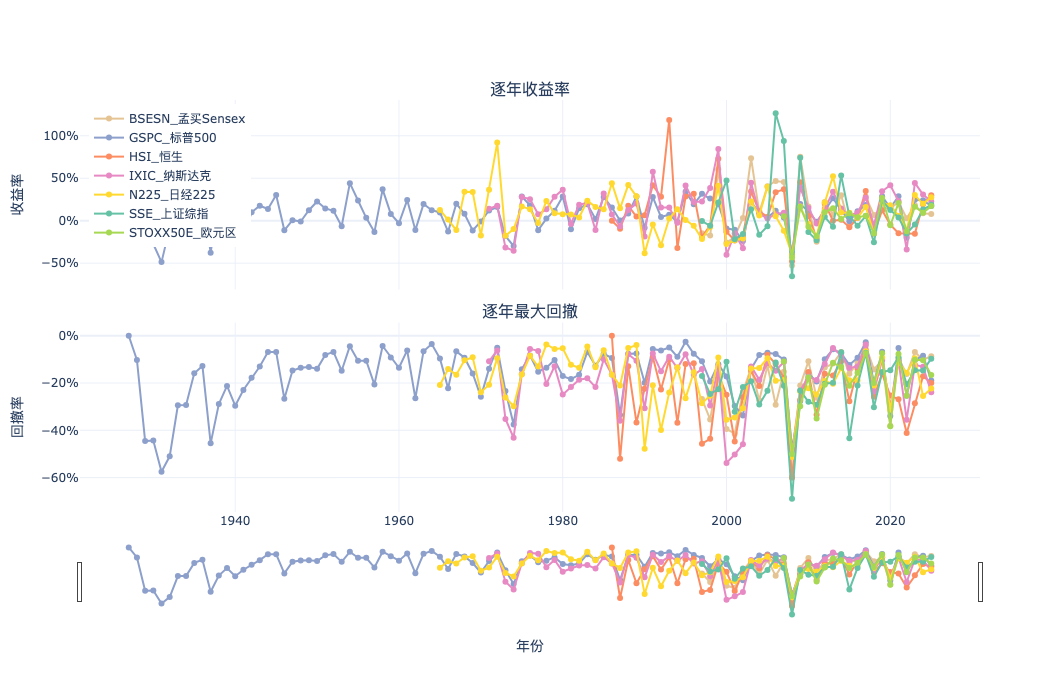

In [14]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08, subplot_titles=("逐年收益率", "逐年最大回撤"))

x_years = pd.to_datetime(yearly_df_pivot_return.index.astype(str))

# 逐年收益（折线）
for col in yearly_df_pivot_return.columns:
    fig.add_trace(
        go.Scatter(
            x=x_years,
            y=yearly_df_pivot_return[col],
            mode="lines+markers",
            name=col,
            line=dict(color=color_map.get(col), width=2),
            marker=dict(size=6),
            hovertemplate="指数: %{fullData.name}<br>年份: %{x|%Y}<br>收益率: %{y:.2%}<extra></extra>",
        ),
        row=1,
        col=1,
    )

# 逐年最大回撤（折线）
for col in yearly_df_pivot_dd.columns:
    fig.add_trace(
        go.Scatter(
            x=x_years,
            y=yearly_df_pivot_dd[col],
            mode="lines+markers",
            name=col,
            line=dict(color=color_map.get(col), width=2),
            marker=dict(size=6),
            hovertemplate="指数: %{fullData.name}<br>年份: %{x|%Y}<br>最大回撤: %{y:.2%}<extra></extra>",
            showlegend=False,
        ),
        row=2,
        col=1,
    )

fig.update_layout(
    template="plotly_white",
    height=700,
    width=1080,
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.update_yaxes(title_text="收益率", tickformat=".0%", row=1, col=1)
fig.update_yaxes(title_text="回撤率", tickformat=".0%", row=2, col=1)
fig.update_xaxes(title_text="年份", tickformat="%Y", rangeslider=dict(visible=True), row=2, col=1)
fig.show()